--- Ideal Simulation Results ---
{'00': 520, '11': 480}

--- Spinning up Noisy Hardware Model ---
--- Noisy 'Real' Hardware Results ---
{'01': 4, '11': 499, '10': 6, '00': 491}


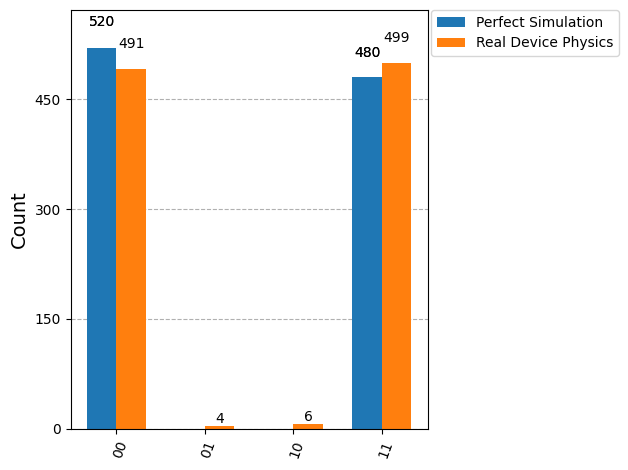

In [1]:
# --- Day 20: The Grand Finale (Ideal vs. Noisy Hardware) ---
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.providers.fake_provider import GenericBackendV2

# 1. Build the Bell State Circuit
# Simple, but sensitive to noise.
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()

# 2. Simulation A: The Perfect World
# This is what we have done for 19 days.
ideal_sim = AerSimulator()
ideal_result = ideal_sim.run(transpile(qc, ideal_sim), shots=1000).result()
ideal_counts = ideal_result.get_counts()

print("--- Ideal Simulation Results ---")
print(ideal_counts)

# 3. Simulation B: The Real World (Noisy)
# We create a "Fake" backend that mimics a 5-qubit device with errors.
# This simulates thermal relaxation (T1/T2), gate errors, and readout errors.
print("\n--- Spinning up Noisy Hardware Model ---")
noisy_backend = GenericBackendV2(num_qubits=5, basis_gates=['cz', 'id', 'rz', 'sx', 'x'])

# We must transpile specifically for this chip's topology (how qubits are connected)
qc_noisy = transpile(qc, noisy_backend)

# Run the simulator using the noise model of the fake backend
real_sim = AerSimulator.from_backend(noisy_backend)
real_result = real_sim.run(qc_noisy, shots=1000).result()
real_counts = real_result.get_counts()

print("--- Noisy 'Real' Hardware Results ---")
print(real_counts)

# 4. Compare the Reality
# In a perfect world, we only see '00' and '11'.
# In the real world, you will see '01' and '10' (Errors!).
legend = ['Perfect Simulation', 'Real Device Physics']
display(plot_histogram([ideal_counts, real_counts], legend=legend))